In [1]:
import pandas as pd
import numpy as np
import pickle
from catboost import CatBoostRegressor
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
train_df = pd.read_csv("./datasets/train.csv")
test_df  = pd.read_csv("./datasets/test.csv")

print("Train shape:", train_df.shape)
print("Test shape :", test_df.shape)

target = "price"   

X = train_df.drop(columns=[target])
y = train_df[target]

Train shape: (100000, 19)
Test shape : (100000, 18)


In [3]:
def preprocess_for_catboost(df):
    df = df.copy()

    # Binary columns → 0 / 1
    binary_cols = ["gas", "hot_water", "central_heating"]
    binary_map = {
        "yes": 1, "no": 0,
        "true": 1, "false": 0,
        1: 1, 0: 0
    }

    for col in binary_cols:
        if col in df.columns:
            df[col] = (
                df[col]
                .astype(str)
                .str.lower()
                .map(binary_map)
                .fillna(0)
                .astype(int)
            )
    
    # Flat age
    df["flat_age"] = 2023 - pd.to_numeric(df["year"], errors="coerce")
    df["flat_age"] = df["flat_age"].fillna(0)

    # Categorical columns → string
    cat_cols = ["district_name", "extra_area_type_name"]
    for col in cat_cols:
        if col in df.columns:
            df[col] = df[col].astype(str).fillna("Unknown")

    # Numeric columns
    numeric_cols = [
        "rooms_count", "total_area", "kitchen_area", "bath_area",
        "other_area", "extra_area", "extra_area_count",
        "floor", "floor_max", "ceil_height", "bath_count"
    ]

    for col in numeric_cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")

    df[numeric_cols] = df[numeric_cols].fillna(0)

    return df





In [4]:
train_df = preprocess_for_catboost(train_df)
test_df  = preprocess_for_catboost(test_df)

In [5]:
features = [
    "district_name",
    "rooms_count",
    "total_area",
    "kitchen_area",
    "bath_area",
    "other_area",
    "extra_area",
    "extra_area_count",
    "floor",
    "floor_max",
    "ceil_height",
    "bath_count",
    "flat_age",
    "gas",
    "hot_water",
    "central_heating",
    "extra_area_type_name"
]

target = "price"

X = train_df[features]
y = train_df[target]
X_test = test_df[features]

# Categorical feature indices
cat_features = [
    features.index("district_name"),
    features.index("extra_area_type_name")
]

In [6]:
encoders = {}
cat_features = []

for col in ["district_name", "extra_area_type_name"]:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])
    X_test[col] = X_test[col].map(
        lambda x: le.transform([x])[0] if x in le.classes_ else -1
    )
    encoders[col] = le
    cat_features.append(features.index(col))

C:\Users\archa\AppData\Local\Temp\ipykernel_30568\941684625.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[col] = le.fit_transform(X[col])
C:\Users\archa\AppData\Local\Temp\ipykernel_30568\941684625.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_test[col] = X_test[col].map(
C:\Users\archa\AppData\Local\Temp\ipykernel_30568\941684625.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the 

In [7]:

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [23]:
cat_model = CatBoostRegressor(
    iterations=5000,
    learning_rate=0.03,
    depth=8,
    loss_function="RMSE",
    eval_metric="RMSE",
    random_seed=42,
    early_stopping_rounds=200,
    verbose=200
)

In [24]:
cat_model.fit(
    X_train, y_train,
    cat_features=cat_features,
    eval_set=(X_val, y_val),
    use_best_model=True
)

0:	learn: 5822480.2815414	test: 5781614.6015734	best: 5781614.6015734 (0)	total: 129ms	remaining: 10m 45s
200:	learn: 301580.6603300	test: 251535.0780312	best: 251535.0780312 (200)	total: 38.5s	remaining: 15m 19s
400:	learn: 242636.6037146	test: 192953.0382290	best: 192953.0382290 (400)	total: 1m 9s	remaining: 13m 20s
600:	learn: 222630.9683350	test: 180793.8367323	best: 180793.8367323 (600)	total: 1m 39s	remaining: 12m 8s
800:	learn: 204356.2275336	test: 172575.9852985	best: 172575.9852985 (800)	total: 2m 9s	remaining: 11m 20s
1000:	learn: 190925.6083701	test: 168473.1400757	best: 168473.1400757 (1000)	total: 2m 39s	remaining: 10m 38s
1200:	learn: 184473.4596311	test: 165536.3902185	best: 165536.3902185 (1200)	total: 3m 11s	remaining: 10m 4s
1400:	learn: 179094.2158947	test: 163296.7542759	best: 163296.7542759 (1400)	total: 3m 43s	remaining: 9m 32s
1600:	learn: 175107.3495725	test: 161759.9374851	best: 161759.9374851 (1600)	total: 4m 14s	remaining: 9m
1800:	learn: 170608.5778136	test:

In [25]:
val_preds = cat_model.predict(X_val)

mae  = mean_absolute_error(y_val, val_preds)
rmse = np.sqrt(mean_squared_error(y_val, val_preds))
r2   = r2_score(y_val, val_preds)

print("\nCatBoost Evaluation:")
print("MAE :", mae)
print("RMSE:", rmse)
print("R²  :", r2)


CatBoost Evaluation:
MAE : 131019.90070188756
RMSE: 155949.75732341432
R²  : 0.9993115141361073


In [26]:
test_preds = cat_model.predict(X_test)


submission = pd.DataFrame({
    "index": test_df.index,
    "price": test_preds
})

submission.to_csv("datasets/predictions_catboost.csv", index=False)

print("\n✅ predictions_catboost.csv saved successfully!")


✅ predictions_catboost.csv saved successfully!


In [27]:

with open("model_catboost.pkl", "wb") as f:
    pickle.dump(cat_model, f)

with open("encoders.pkl", "wb") as f:
    pickle.dump(encoders, f)

print("✅ model_catboost.pkl & encoders.pkl saved")

✅ model_catboost.pkl & encoders.pkl saved


In [28]:
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

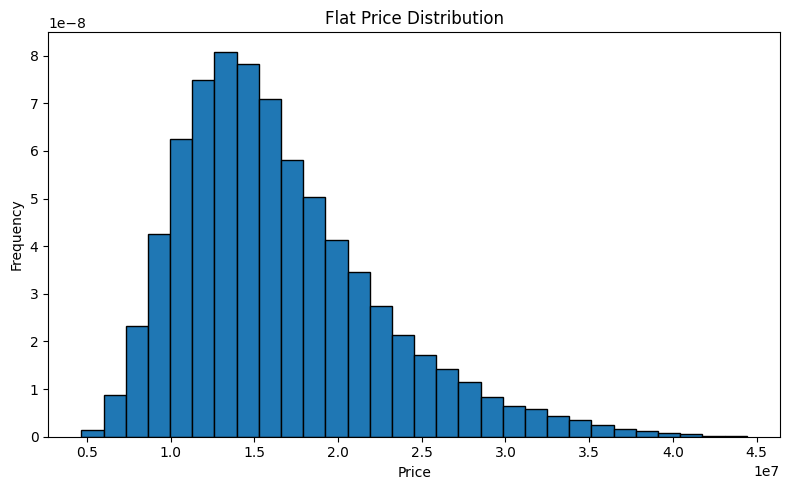

In [30]:
# HISTOGRAM – PRICE
plt.figure(figsize=(8, 5))
plt.hist(
    train_df['price'],
    bins=30,
    edgecolor='black',
    density=True
)
plt.title('Flat Price Distribution')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.tight_layout()
plt.savefig("img/price_distribution.png", dpi=300)
plt.show()
plt.close()

In [17]:
# HISTOGRAM – TOTAL AREA
plt.figure(figsize=(8, 5))
plt.hist(
    train_df['total_area'],
    bins=30,
    edgecolor='black'
)
plt.title('Total Area Distribution')
plt.xlabel('Total Area (sq.m)')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig("img/total_area_distribution.png", dpi=300)
plt.close()


In [18]:
plt.figure(figsize=(8, 5))
plt.hist(
    train_df['year'],
    bins=30,
    edgecolor='black',
    density=True
)
plt.title('Year of Construction Distribution')
plt.xlabel('Year')
plt.ylabel('Frequency')
plt.tight_layout()
plt.savefig("img/year_distribution.png", dpi=300)
plt.close()

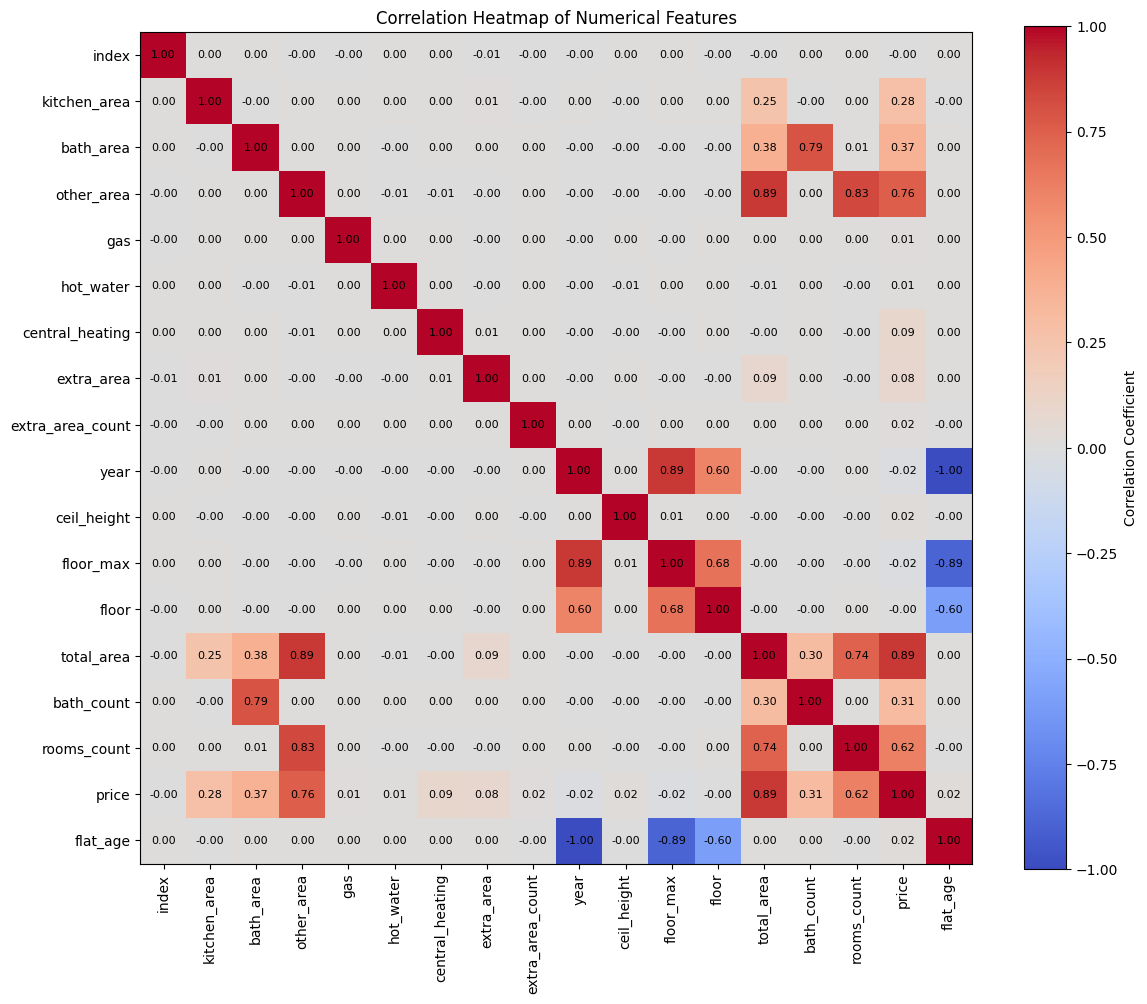

In [21]:
# Select all numeric columns automatically
numeric_data = train_df.select_dtypes(include='number')

# Compute correlation matrix
corr = numeric_data.corr()

# Plot heatmap
plt.figure(figsize=(12, 10))
plt.imshow(corr, cmap='coolwarm', interpolation='nearest')
plt.colorbar(label='Correlation Coefficient')

# Axis labels
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)

# Add correlation values inside cells
for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        plt.text(
            j, i,
            f"{corr.iloc[i, j]:.2f}",
            ha="center",
            va="center",
            fontsize=8
        )

plt.title("Correlation Heatmap of Numerical Features")
plt.tight_layout()
plt.savefig("img/correlation_heatmap.png", dpi=300)
plt.show()

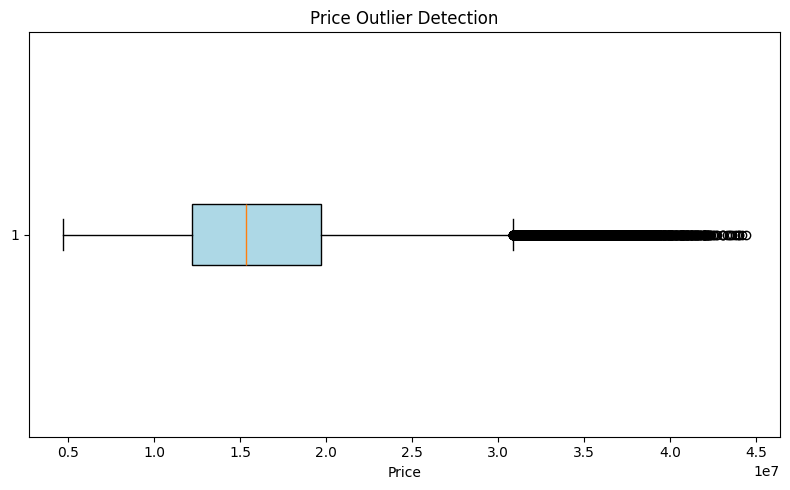

In [22]:
plt.figure(figsize=(8, 5))
plt.boxplot(
    train_df['price'],
    vert=False,
    patch_artist=True,
    boxprops=dict(facecolor='lightblue')
)
plt.title('Price Outlier Detection')
plt.xlabel('Price')
plt.tight_layout()
plt.savefig("img/price_outliers.png", dpi=300)
plt.show()